In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split,
                                     cross_val_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              ConfusionMatrixDisplay,
                              roc_curve,
                              roc_auc_score,
                              accuracy_score,
                              precision_score,
                              recall_score,
                              f1_score)
import warnings
warnings.filterwarnings('ignore')

# ── Load credentials ─────────────────────────────────
load_dotenv(r"C:\Users\Administrator\Desktop\kenya_road_safety_project\.env")

# ── Plot style ───────────────────────────────────────
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# ── Paths ────────────────────────────────────────────
BASE_DIR   = r"C:\Users\Administrator\Desktop\kenya_road_safety_project"
CLEAN_DATA = os.path.join(BASE_DIR, "data", "cleaned", "accidents_clean.csv")
VISUALS    = os.path.join(BASE_DIR, "visuals")
os.makedirs(VISUALS, exist_ok=True)

# ── Database connection ──────────────────────────────
connection_url = URL.create(
    drivername = "postgresql+psycopg2",
    username   = os.getenv("DB_USER"),
    password   = os.getenv("DB_PASSWORD"),
    host       = os.getenv("DB_HOST"),
    port       = int(os.getenv("DB_PORT")),
    database   = os.getenv("DB_NAME")
)
engine = create_engine(connection_url)

# ── Load cleaned data ────────────────────────────────
df = pd.read_csv(CLEAN_DATA)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Data loaded successfully")
print("Shape:", df.shape)

Data loaded successfully
Shape: (1119, 20)


In [2]:
# ── Fill nulls before encoding ───────────────────────
df['county']          = df['county'].fillna('Unknown')
df['cause_code']      = df['cause_code'].fillna('Unknown')
df['victim_category'] = df['victim_category'].fillna('Unknown')
df['time_of_day']     = df['time_of_day'].fillna('Unknown')
df['road']            = df['road'].fillna('Unknown')
df['hour']            = df['hour'].fillna(0)
df['num_victims']     = df['num_victims'].fillna(1)

# ── Encode categorical columns ───────────────────────
le_county  = LabelEncoder()
le_cause   = LabelEncoder()
le_victim  = LabelEncoder()
le_time    = LabelEncoder()
le_road    = LabelEncoder()

df['county_encoded']  = le_county.fit_transform(df['county'])
df['cause_encoded']   = le_cause.fit_transform(
                         df['cause_code'].astype(str))
df['victim_encoded']  = le_victim.fit_transform(df['victim_category'])
df['time_encoded']    = le_time.fit_transform(df['time_of_day'])
df['road_encoded']    = le_road.fit_transform(df['road'])

print("Encoding complete")
print(f"County categories  : {len(le_county.classes_)}")
print(f"Cause categories   : {len(le_cause.classes_)}")
print(f"Victim categories  : {len(le_victim.classes_)}")
print(f"Road categories    : {len(le_road.classes_)}")

Encoding complete
County categories  : 43
Cause categories   : 74
Victim categories  : 7
Road categories    : 716


In [3]:
# ── Define features and target ───────────────────────
features = [
    'hour',
    'county_encoded',
    'cause_encoded',
    'victim_encoded',
    'time_encoded',
    'road_encoded',
    'num_victims'
]

feature_names = [
    'Hour of Day',
    'County',
    'Cause Code',
    'Victim Type',
    'Time of Day',
    'Road',
    'Number of Victims'
]

df_model = df[features + ['is_fatal']].dropna()

X = df_model[features]
y = df_model['is_fatal']

# ── Train test split ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print("="*55)
print("DATASET SUMMARY")
print("="*55)
print(f"Total records     : {len(df_model)}")
print(f"Training samples  : {len(X_train)}")
print(f"Testing samples   : {len(X_test)}")
print(f"Fatal rate        : {y.mean()*100:.1f}%")
print(f"\nClass distribution:")
print(f"  Not Fatal (0)   : {(y==0).sum()}")
print(f"  Fatal     (1)   : {(y==1).sum()}")

DATASET SUMMARY
Total records     : 1119
Training samples  : 895
Testing samples   : 224
Fatal rate        : 14.2%

Class distribution:
  Not Fatal (0)   : 960
  Fatal     (1)   : 159


In [4]:
# ── Train Random Forest ──────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators  = 100,       # number of trees
    max_depth     = 10,        # max depth per tree
    min_samples_split = 10,    # min samples to split
    min_samples_leaf  = 5,     # min samples at leaf
    max_features  = 'sqrt',    # features per split
    class_weight  = 'balanced',# handle imbalance
    random_state  = 42,
    n_jobs        = -1         # use all CPU cores
)

rf_model.fit(X_train, y_train)

# ── Predictions ──────────────────────────────────────
y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully")
print(f"Number of trees   : {rf_model.n_estimators}")
print(f"Number of features: {rf_model.n_features_in_}")

Random Forest trained successfully
Number of trees   : 100
Number of features: 7


In [5]:
# ── Calculate all metrics ────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_pred_proba)

print("="*55)
print("MODEL EVALUATION — RANDOM FOREST")
print("="*55)
print(f"Accuracy   : {acc:.4f}  ({acc*100:.1f}%)")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"AUC-ROC    : {auc:.4f}")
print()
print("Full Classification Report:")
print("-"*55)
print(classification_report(
    y_test, y_pred,
    target_names=['Not Fatal', 'Fatal'],
    zero_division=0
))

MODEL EVALUATION — RANDOM FOREST
Accuracy   : 0.8304  (83.0%)
Precision  : 0.3846
Recall     : 0.3125
F1 Score   : 0.3448
AUC-ROC    : 0.7358

Full Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

   Not Fatal       0.89      0.92      0.90       192
       Fatal       0.38      0.31      0.34        32

    accuracy                           0.83       224
   macro avg       0.64      0.61      0.62       224
weighted avg       0.82      0.83      0.82       224



In [6]:
# ── 5-Fold Cross Validation ──────────────────────────
# More reliable than single train-test split
# Tests model on 5 different data splits

print("Running 5-Fold Cross Validation...")
print("This may take a moment...")

cv_scores = cross_val_score(
    rf_model, X, y,
    cv      = 5,
    scoring = 'f1'
)

print()
print("="*55)
print("5-FOLD CROSS VALIDATION RESULTS")
print("="*55)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}  : {score:.4f}")
print("-"*55)
print(f"  Mean F1 : {cv_scores.mean():.4f}")
print(f"  Std Dev : {cv_scores.std():.4f}")
print()
print("A low std dev means the model is stable")
print("across different data splits")

Running 5-Fold Cross Validation...
This may take a moment...

5-FOLD CROSS VALIDATION RESULTS
  Fold 1  : 0.3590
  Fold 2  : 0.3729
  Fold 3  : 0.2105
  Fold 4  : 0.1667
  Fold 5  : 0.1961
-------------------------------------------------------
  Mean F1 : 0.2610
  Std Dev : 0.0869

A low std dev means the model is stable
across different data splits


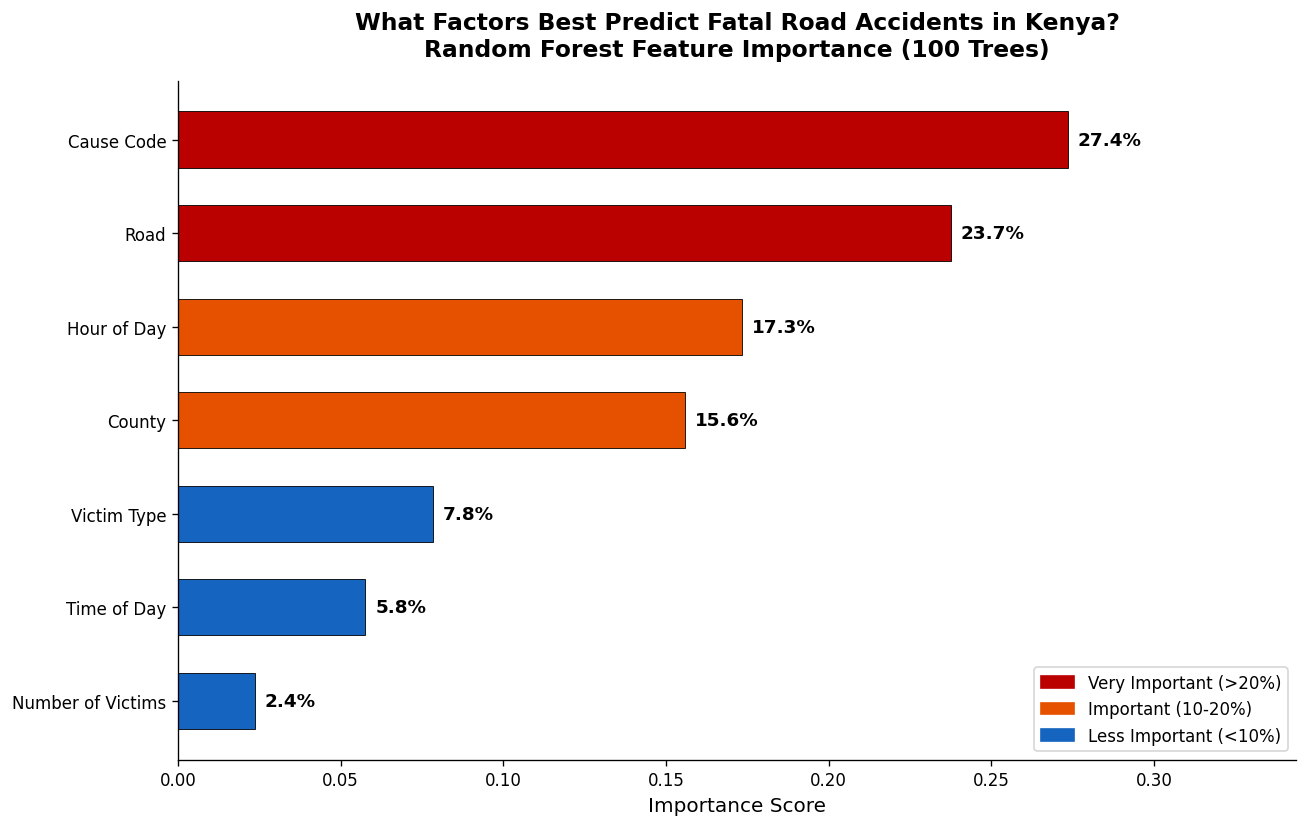

Chart saved


In [7]:
importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Colour by importance level
colors = []
for val in importance_df['Importance']:
    if val >= 0.20:
        colors.append('#BB0000')    # red — very important
    elif val >= 0.10:
        colors.append('#E65100')    # orange — important
    else:
        colors.append('#1565C0')    # blue — less important

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=colors, edgecolor='black',
    linewidth=0.5, height=0.6
)

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height()/2,
        f'{val*100:.1f}%', va='center',
        fontsize=11, fontweight='bold'
    )

ax.set_title(
    'What Factors Best Predict Fatal Road Accidents in Kenya?\n'
    'Random Forest Feature Importance (100 Trees)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_xlim(0, importance_df['Importance'].max() + 0.07)

from matplotlib.patches import Patch
legend = [
    Patch(color='#BB0000', label='Very Important (>20%)'),
    Patch(color='#E65100', label='Important (10-20%)'),
    Patch(color='#1565C0', label='Less Important (<10%)')
]
ax.legend(handles=legend, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'rf_feature_importance.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

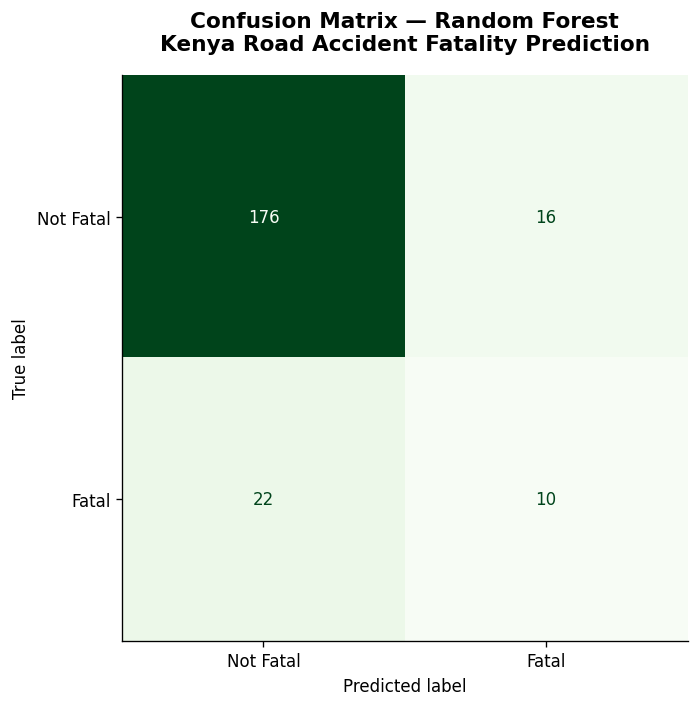

Confusion Matrix Breakdown:
  Correctly predicted Not Fatal : 176
  Correctly predicted Fatal     : 10
  False alarms                  : 16
  Missed fatals                 : 22


In [8]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ['Not Fatal', 'Fatal']
)
disp.plot(cmap='Greens', colorbar=False, ax=ax)

ax.set_title(
    'Confusion Matrix — Random Forest\n'
    'Kenya Road Accident Fatality Prediction',
    fontsize=13, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'rf_confusion_matrix.png'),
            bbox_inches='tight')
plt.show()

print("Confusion Matrix Breakdown:")
print(f"  Correctly predicted Not Fatal : {tn}")
print(f"  Correctly predicted Fatal     : {tp}")
print(f"  False alarms                  : {fp}")
print(f"  Missed fatals                 : {fn}")

Training models with different tree counts...
  Trees=1     → Test accuracy: 0.812
  Trees=5     → Test accuracy: 0.844
  Trees=10    → Test accuracy: 0.862
  Trees=20    → Test accuracy: 0.853
  Trees=30    → Test accuracy: 0.857
  Trees=50    → Test accuracy: 0.857
  Trees=75    → Test accuracy: 0.853
  Trees=100   → Test accuracy: 0.853
  Trees=150   → Test accuracy: 0.857
  Trees=200   → Test accuracy: 0.857


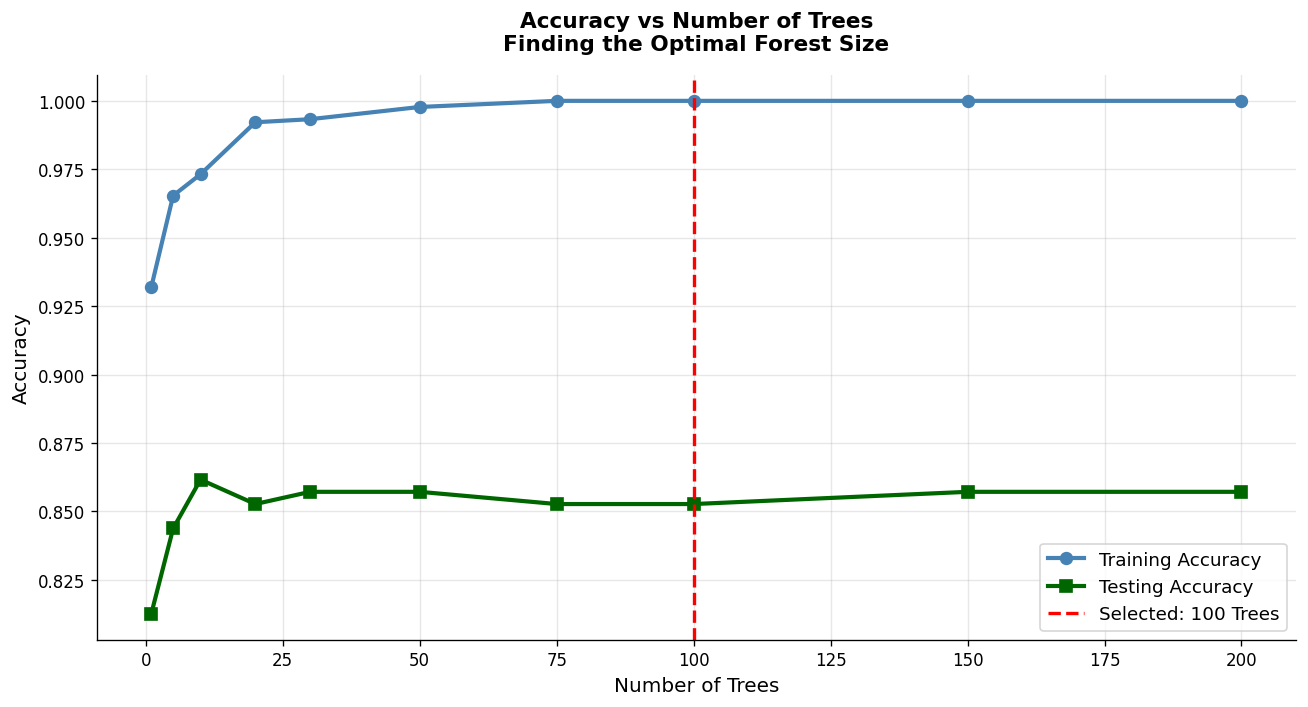

Chart saved


In [9]:
# Show how accuracy improves as more trees are added
# Justifies choice of 100 trees

train_scores = []
test_scores  = []
tree_counts  = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

print("Training models with different tree counts...")
for n in tree_counts:
    rf = RandomForestClassifier(
        n_estimators  = n,
        class_weight  = 'balanced',
        random_state  = 42,
        n_jobs        = -1
    )
    rf.fit(X_train, y_train)
    train_scores.append(rf.score(X_train, y_train))
    test_scores.append(rf.score(X_test,  y_test))
    print(f"  Trees={n:<5} → Test accuracy: "
          f"{test_scores[-1]:.3f}")

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(tree_counts, train_scores,
        'o-', color='steelblue', linewidth=2.5,
        markersize=7, label='Training Accuracy')
ax.plot(tree_counts, test_scores,
        's-', color='#006600', linewidth=2.5,
        markersize=7, label='Testing Accuracy')
ax.axvline(x=100, color='red',
           linestyle='--', linewidth=2,
           label='Selected: 100 Trees')

ax.set_title(
    'Accuracy vs Number of Trees\n'
    'Finding the Optimal Forest Size',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Number of Trees', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'rf_trees_vs_accuracy.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

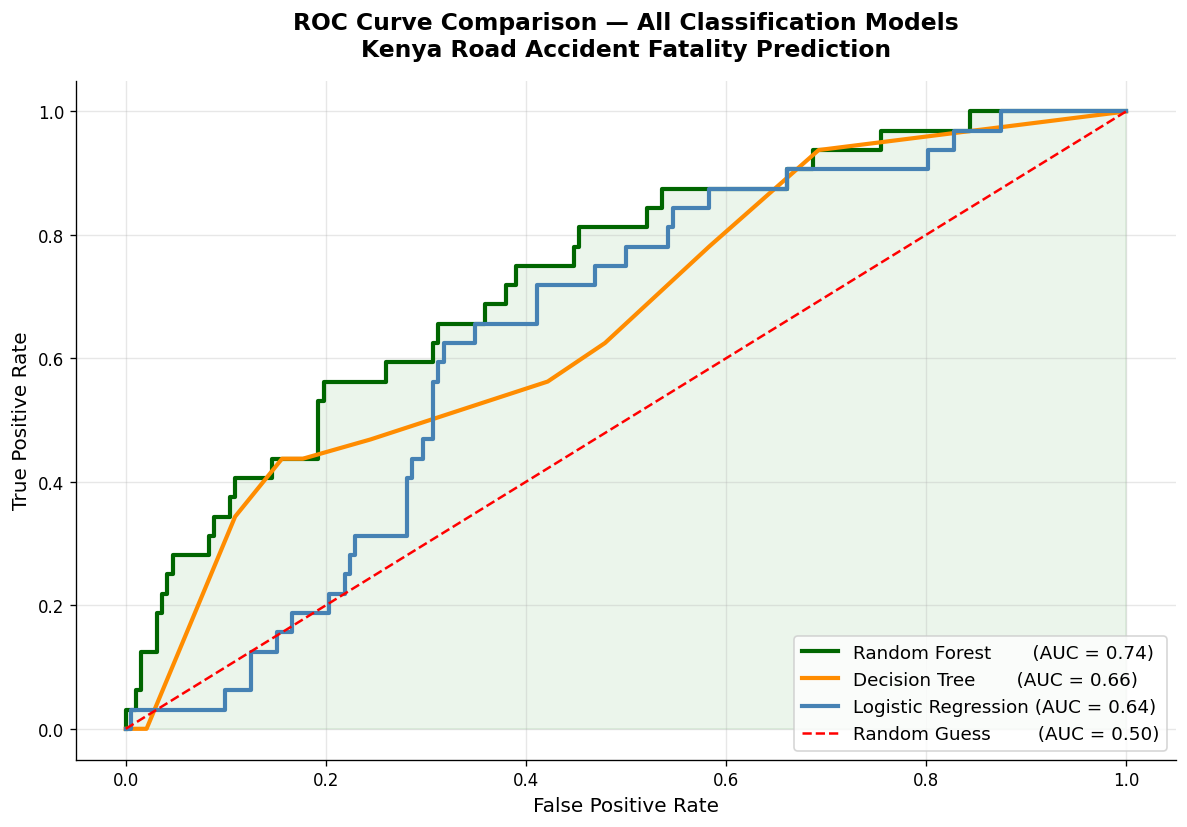

AUC — Random Forest       : 0.7358
AUC — Decision Tree       : 0.6636
AUC — Logistic Regression : 0.6405
Chart saved


In [10]:
# Compare all 3 classification models on one chart
# This is one of the strongest visuals in your project

# ── Retrain Logistic Regression & Decision Tree ──────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train, y_train)

# ── Get probabilities for all models ─────────────────
lr_proba = lr_model.predict_proba(X_test)[:, 1]
dt_proba = dt_model.predict_proba(X_test)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

auc_lr = roc_auc_score(y_test, lr_proba)
auc_dt = roc_auc_score(y_test, dt_proba)
auc_rf = roc_auc_score(y_test, rf_proba)

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(fpr_rf, tpr_rf,
        color='#006600', linewidth=2.5,
        label=f'Random Forest       (AUC = {auc_rf:.2f})')
ax.plot(fpr_dt, tpr_dt,
        color='darkorange', linewidth=2.5,
        label=f'Decision Tree       (AUC = {auc_dt:.2f})')
ax.plot(fpr_lr, tpr_lr,
        color='steelblue', linewidth=2.5,
        label=f'Logistic Regression (AUC = {auc_lr:.2f})')
ax.plot([0, 1], [0, 1],
        color='red', linewidth=1.5,
        linestyle='--',
        label='Random Guess        (AUC = 0.50)')

ax.fill_between(fpr_rf, tpr_rf,
                alpha=0.08, color='green')

ax.set_title(
    'ROC Curve Comparison — All Classification Models\n'
    'Kenya Road Accident Fatality Prediction',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'rf_roc_comparison.png'),
            bbox_inches='tight')
plt.show()
print(f"AUC — Random Forest       : {auc_rf:.4f}")
print(f"AUC — Decision Tree       : {auc_dt:.4f}")
print(f"AUC — Logistic Regression : {auc_lr:.4f}")
print("Chart saved")

In [11]:
# ── Compare all 3 models side by side ────────────────
lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

results = {
    'Model': [
        'Logistic Regression',
        'Decision Tree (depth=5)',
        'Random Forest (100 trees)'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred, zero_division=0),
        precision_score(y_test, dt_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, lr_pred, zero_division=0),
        recall_score(y_test, dt_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred, zero_division=0),
        f1_score(y_test, dt_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ],
    'AUC-ROC': [auc_lr, auc_dt, auc_rf]
}

results_df = pd.DataFrame(results)

print("="*75)
print("FINAL MODEL COMPARISON TABLE")
print("="*75)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))
print("="*75)

# Find best model
best_idx  = results_df['AUC-ROC'].idxmax()
best_name = results_df.loc[best_idx, 'Model']
best_auc  = results_df.loc[best_idx, 'AUC-ROC']
print(f"\nBest Model : {best_name}")
print(f"Best AUC   : {best_auc:.4f}")

# Save results to CSV for Power BI
results_df.to_csv(
    os.path.join(BASE_DIR, 'data', 'exports',
                 'model_comparison.csv'),
    index=False
)
print("\nModel comparison saved to exports/model_comparison.csv")

FINAL MODEL COMPARISON TABLE
                    Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
      Logistic Regression    0.6071     0.2255  0.7188    0.3433   0.6405
  Decision Tree (depth=5)    0.7143     0.2419  0.4688    0.3191   0.6636
Random Forest (100 trees)    0.8304     0.3846  0.3125    0.3448   0.7358

Best Model : Random Forest (100 trees)
Best AUC   : 0.7358

Model comparison saved to exports/model_comparison.csv


In [12]:
def assess_risk(hour, county, cause,
                victim, time_of_day,
                road, num_victims):
    try:
        input_data = pd.DataFrame([{
            'hour'           : hour,
            'county_encoded' : le_county.transform(
                                [county])[0],
            'cause_encoded'  : le_cause.transform(
                                [str(cause)])[0],
            'victim_encoded' : le_victim.transform(
                                [victim])[0],
            'time_encoded'   : le_time.transform(
                                [time_of_day])[0],
            'road_encoded'   : le_road.transform(
                                [road])[0],
            'num_victims'    : num_victims
        }])

        probability = rf_model.predict_proba(
                          input_data)[0][1]
        prediction  = rf_model.predict(input_data)[0]

        if probability >= 0.75:   risk = "CRITICAL RISK"
        elif probability >= 0.50: risk = "HIGH RISK"
        elif probability >= 0.25: risk = "MEDIUM RISK"
        else:                     risk = "LOW RISK"

        print("="*52)
        print("  RANDOM FOREST — RISK ASSESSMENT")
        print("="*52)
        print(f"  County       : {county}")
        print(f"  Time         : {hour:02d}:00 ({time_of_day})")
        print(f"  Road         : {road}")
        print(f"  Cause Code   : {cause}")
        print(f"  Victim Type  : {victim}")
        print(f"  Num Victims  : {num_victims}")
        print("-"*52)
        print(f"  Fatal Prob   : {probability*100:.1f}%")
        print(f"  Prediction   : "
              f"{'FATAL' if prediction==1 else 'NOT FATAL'}")
        print(f"  Risk Level   : {risk}")
        print("="*52)

    except ValueError as e:
        print(f"Input error: {e}")

# ── Test with two scenarios ──────────────────────────
print("SCENARIO 1 — High risk conditions")
assess_risk(
    hour        = 22,
    county      = 'NAIROBI',
    cause       = '10',
    victim      = 'Motorcyclist',
    time_of_day = 'Night',
    road        = 'NAKURU-NAIROBI',
    num_victims = 2
)

print()
print("SCENARIO 2 — Lower risk conditions")
assess_risk(
    hour        = 9,
    county      = 'MOMBASA',
    cause       = '26',
    victim      = 'Passenger',
    time_of_day = 'Morning',
    road        = 'MOMBASA-NAIROBI',
    num_victims = 1
)

SCENARIO 1 — High risk conditions
  RANDOM FOREST — RISK ASSESSMENT
  County       : NAIROBI
  Time         : 22:00 (Night)
  Road         : NAKURU-NAIROBI
  Cause Code   : 10
  Victim Type  : Motorcyclist
  Num Victims  : 2
----------------------------------------------------
  Fatal Prob   : 53.2%
  Prediction   : FATAL
  Risk Level   : HIGH RISK

SCENARIO 2 — Lower risk conditions
  RANDOM FOREST — RISK ASSESSMENT
  County       : MOMBASA
  Time         : 09:00 (Morning)
  Road         : MOMBASA-NAIROBI
  Cause Code   : 26
  Victim Type  : Passenger
  Num Victims  : 1
----------------------------------------------------
  Fatal Prob   : 46.2%
  Prediction   : NOT FATAL
  Risk Level   : MEDIUM RISK


In [13]:
print("="*55)
print("NOTEBOOK 7 COMPLETE — RANDOM FOREST")
print("="*55)
print(f"\nModel         : Random Forest (100 trees)")
print(f"Target        : is_fatal (0=Not Fatal, 1=Fatal)")
print(f"Features used : {len(features)}")
print(f"Training size : {len(X_train)}")
print(f"Testing size  : {len(X_test)}")
print()
print("Evaluation Results:")
print(f"  Accuracy   : {acc:.4f}")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1 Score   : {f1:.4f}")
print(f"  AUC-ROC    : {auc:.4f}")
print()
print(f"Cross Val F1  : {cv_scores.mean():.4f} "
      f"(+/- {cv_scores.std():.4f})")
print()
print("Charts saved:")
print("  rf_feature_importance.png")
print("  rf_confusion_matrix.png")
print("  rf_trees_vs_accuracy.png")
print("  rf_roc_comparison.png")
print()
print("Exports saved:")
print("  data/exports/model_comparison.csv")
print()
print("Next → Notebook 8: K-Means Clustering")

NOTEBOOK 7 COMPLETE — RANDOM FOREST

Model         : Random Forest (100 trees)
Target        : is_fatal (0=Not Fatal, 1=Fatal)
Features used : 7
Training size : 895
Testing size  : 224

Evaluation Results:
  Accuracy   : 0.8304
  Precision  : 0.3846
  Recall     : 0.3125
  F1 Score   : 0.3448
  AUC-ROC    : 0.7358

Cross Val F1  : 0.2610 (+/- 0.0869)

Charts saved:
  rf_feature_importance.png
  rf_confusion_matrix.png
  rf_trees_vs_accuracy.png
  rf_roc_comparison.png

Exports saved:
  data/exports/model_comparison.csv

Next → Notebook 8: K-Means Clustering
